In [9]:
import fslatency_analyzer
import darshan
import seaborn as sb
import pandas as pd
import darshan.backend.cffi_backend as backend

darshan.enable_experimental()
from glob import glob
from darshan_helpers import load_dataframe, load_dataframe_dxt
from darshan_helpers import METADATA_COLUMNS
from fslatency_analyzer import main

In [14]:
import sys
import pandas as pd

from fslatency_analyzer import main as latency_analysis

baseline_sim_runs = glob("/home/wkwiecinski/projects/data/exps/sim_baseline/*/sim_run/*.darshan", recursive=True)
weak_scaling_experiment_runs = glob("/home/wkwiecinski/projects/data/exps/weak_scaling/sharedfs/**/subrun/*.darshan", recursive=True)
strong_scaling_experiment_runs = glob("/home/wkwiecinski/projects/data/exps/strong_scaling/sharedfs/**/subrun/*.darshan", recursive=True)

# bests = []
df = pd.DataFrame()

# inject commandline arguments to fslatency_analyzer
for log in baseline_sim_runs:
    print("Probing base...")
    sys.argv = ["fs_latency_analyzer.py", f"{log}"]
    base_best = latency_analysis()
    for base in base_best:
        # print(base)
        # for candidate in base_best["candidates"]:
        # separate occurrences
        occs_df = pd.DataFrame(base["occurrences"])
        sub_df = pd.DataFrame(base).drop("occurrences", axis=1)
        sub_df = pd.merge(sub_df, occs_df, how="left", on="norm_filename")

        # add metadata columns
        sub_df["run"] = "baseline_sim"
        sub_df["nprocs"] = "baseline"
        sub_df["container"] = "none"
        sub_df["experiment"] = "strong_scaling"
        sub_df["fs"] = "eos"

        df = pd.concat([df, sub_df], ignore_index=True)


for log in weak_scaling_experiment_runs:
    print(f"Probing experiment {log}")
    sys.argv = ["fs_latency_analyzer.py", f"{log}"]
    best = latency_analysis()
    for i in best:
        # for candidate in i["candidates"]:
        # separate occurrences
        occs_df = pd.DataFrame(i["occurrences"])
        sub_df = pd.DataFrame(i).drop("occurrences", axis=1)
        sub_df = pd.merge(sub_df, occs_df, how="left", on="norm_filename")

        # 8/apptainer/lustre/1/subrun/112512_python_id742199-742199_5-20-17521-16709895538165009922_1.darshan
        log_parts = log.replace("/home/wkwiecinski/projects/data/exps/weak_scaling/sharedfs/", "").split("/")
        # print(log_parts)
        nprocs = log_parts[0]
        container = log_parts[1]
        fs = log_parts[2]

        # add metadata columns
        sub_df["run"] = "1"
        sub_df["nprocs"] = nprocs
        sub_df["container"] = container
        sub_df["experiment"] = "strong_scaling"
        sub_df["fs"] = fs

        df = pd.concat([df, sub_df], ignore_index=True)

df[df["quality_label"].str.contains("excellent")]


Probing base...
Scanning 1 log(s) with up to 8 worker(s)...
Processing testhits
1048576
Found DXT_POSIX with 2044 records for enrichment
  [1/1] wkwiecin_python_id2443801-2443801_5-16-5381-12677682656559170783_1.darshan — 118 candidate(s)

Selecting best probe per filesystem:
  FS: /eos/home-w                          OP: READ   -> InDetIdDict.xml
    logs: 1/1  temporal_score: 0.14  coverage: 0%  uniformity: 47%  active_periods: 1.0  quality: ☆☆☆ poor — ops too clustered, unreliable probe
  FS: /cvmfs/atlas.cern.ch                 OP: READ   -> ENSDFSTATE.dat
    logs: 1/1  temporal_score: 0.30  coverage: 0%  uniformity: 99%  active_periods: 1.0  quality: ☆☆☆ poor — ops too clustered, unreliable probe
  FS: /cvmfs/atlas-nightlies.cern.ch       OP: READ   -> EVNT.33964680._002197.pool.root.1
    logs: 1/1  temporal_score: 0.89  coverage: 97%  uniformity: 70%  active_periods: 84.0  quality: ★★★ excellent
  FS: /eos/home-w                          OP: WRITE  -> SimParams.db-journal
    l

,mount_pt_x,op_type,norm_filename,n_logs,probe_key,temporal_score_x,temporal_coverage_x,temporal_uniformity_x,active_periods_x,quality_label,...,temporal_coverage_y,temporal_uniformity_y,active_periods_y,ops_per_period,temporal_score_y,run,nprocs,container,experiment,fs
1,/cvmfs/atlas-nightlies.cern.ch,READ,EVNT.33964680._002197.pool.root.1,1,EVNT.33964680._002197.pool.root.1|READ,0.888500,0.966478,0.695378,84.0,★★★ excellent,...,0.966478,0.695378,84,3.059524,0.888500,baseline_sim,baseline,none,strong_scaling,eos
5,/pscratch/sd/w/wkwiecin,WRITE,testHITS.pool.root,1,testHITS.pool.root|WRITE,0.935252,0.943558,0.897056,63.0,★★★ excellent,...,0.943558,0.897056,63,15.158730,0.935252,baseline_sim,baseline,none,strong_scaling,eos
7,/cvmfs/atlas-nightlies.cern.ch,READ,EVNT.33964680._002197.pool.root.1,1,EVNT.33964680._002197.pool.root.1|READ,0.904234,0.967890,0.745000,92.0,★★★ excellent,...,0.967890,0.745000,92,2.793478,0.904234,1,1,apptainer,strong_scaling,lustre
9,/pscratch/sd/w/wkwiecin,WRITE,testHITS.pool.root,1,testHITS.pool.root|WRITE,0.913446,0.916356,0.878772,67.0,★★★ excellent,...,0.916356,0.878772,67,14.179104,0.913446,1,1,apptainer,strong_scaling,lustre
11,/cvmfs/atlas-nightlies.cern.ch,READ,EVNT.33964680._002197.pool.root.1,1,EVNT.33964680._002197.pool.root.1|READ,0.895558,0.975947,0.699964,107.0,★★★ excellent,...,0.975947,0.699964,107,2.401869,0.895558,1,1,podman,strong_scaling,lustre
14,/pscratch/sd/w/wkwiecin,WRITE,testHITS.pool.root,1,testHITS.pool.root|WRITE,0.930102,0.931493,0.904020,72.0,★★★ excellent,...,0.931493,0.904020,72,13.166667,0.930102,1,1,podman,strong_scaling,lustre
16,/cvmfs/atlas-nightlies.cern.ch,READ,EVNT.33964680._002197.pool.root.1,1,EVNT.33964680._002197.pool.root.1|READ,0.898492,0.967420,0.726801,85.0,★★★ excellent,...,0.967420,0.726801,85,3.023529,0.898492,1,1,shifter,strong_scaling,lustre
20,/pscratch/sd/w/wkwiecin,WRITE,testHITS.pool.root,1,testHITS.pool.root|WRITE,0.918242,0.916103,0.895266,61.0,★★★ excellent,...,0.916103,0.895266,61,15.622951,0.918242,1,1,shifter,strong_scaling,lustre
22,/cvmfs/atlas-nightlies.cern.ch,READ,EVNT.33964680._002197.pool.root.1,1,EVNT.33964680._002197.pool.root.1|READ,0.890026,0.969577,0.694267,83.0,★★★ excellent,...,0.969577,0.694267,83,3.096386,0.890026,1,1,none,strong_scaling,eos
26,/pscratch/sd/w/wkwiecin,WRITE,testHITS.pool.root,1,testHITS.pool.root|WRITE,0.935062,0.943526,0.896488,61.0,★★★ excellent,...,0.943526,0.896488,61,15.639344,0.935062,1,1,none,strong_scaling,eos


/tmp/ipykernel_97429/836624009.py:24: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  sub_plotting_data["nprocs"] = sub_plotting_data["nprocs"].astype(int)
/tmp/ipykernel_97429/836624009.py:27: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  sub_plotting_data["fs"] = "cvmfs"
/tmp/ipykernel_97429/836624009.py:24: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.

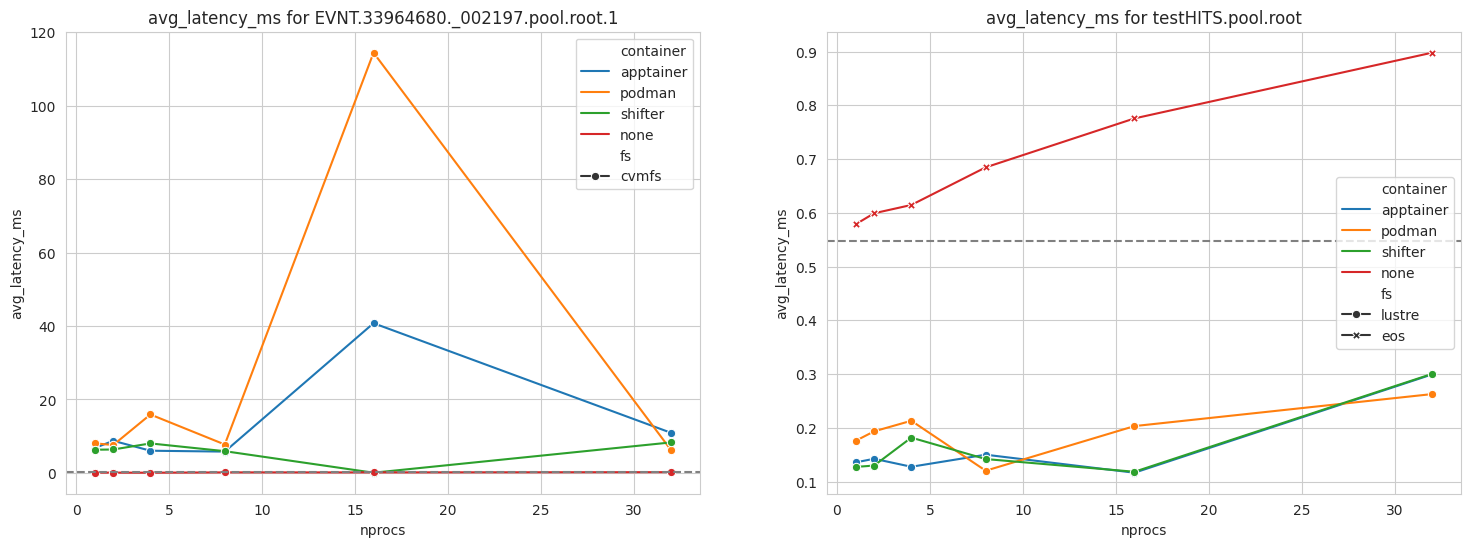

In [ ]:
import seaborn as sb
import matplotlib.pyplot as plt

# plotting_data = df[df["quality_label"].str.contains("excellent")]
plotting_data = df
fig,axes = plt.subplots(ncols=2, figsize=(18, 6))

latency = "p95_latency_ms"

color_map = {
    "apptainer": "blue",
    "shifter": "red",
    "podman": "green",
    "none": "orange"
}

# sb.set_style("whitegrid")

for idx,file in enumerate(["EVNT.33964680._002197.pool.root.1", "testHITS.pool.root"]):

    baseline_latency = plotting_data[(plotting_data["run"].str.contains("baseline_sim")) & (plotting_data["norm_filename"].str.contains(file))][latency].values
    # print(baseline_latency)
    sub_plotting_data = plotting_data[(plotting_data["norm_filename"].str.contains(file)) & (~plotting_data["run"].str.contains("baseline_sim"))]
    sub_plotting_data["nprocs"] = sub_plotting_data["nprocs"].astype(int)

    if file == "EVNT.33964680._002197.pool.root.1":
        sub_plotting_data["fs"] = "cvmfs"

    plot = sb.lineplot(data=sub_plotting_data, x="nprocs", y=latency, hue="container", style="fs", markers=True, dashes=False, ax=axes[idx], color=color_map)
    axes[idx].axhline(baseline_latency, color="gray", linestyle="--", label="Baseline Sim")
    plot.set_title(f"{latency} for {file}")
    # plt.xlabel("Number of Processes")
    # plt.ylabel("Average Latency (ms)")
    # plt.legend(title="Container / FS")
    # plt.show()
# sb.lineplot(data=df[(df["quality_label"].str.contains("excellent")) & (df["norm_filename"].str.contains("testHITS.pool.root"))], x="nprocs", y="avg_latency_ms", hue="container", style="fs", markers=True, dashes=False)